## IMDB Reviews Sentiment Analysis Using NLP and Machine Learning

In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from gensim.models import Word2Vec

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [7]:
df=pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [10]:
df.isnull().sum()

,0
review,0
sentiment,0


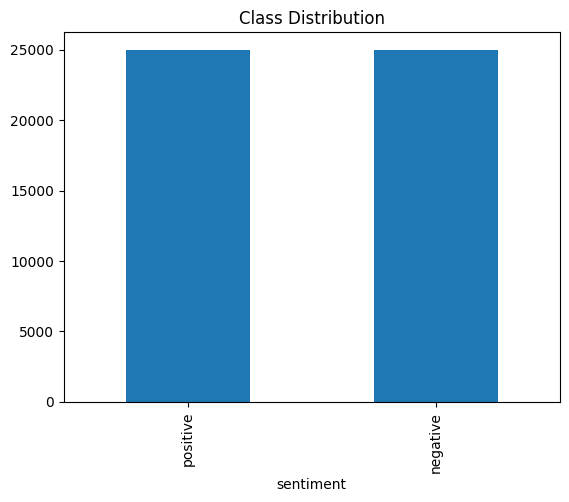

In [11]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [12]:
# Text length Analysis
df["text_length"]=df['review'].apply(len)
df.head()

,review,sentiment,text_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


<Axes: xlabel='text_length', ylabel='Count'>

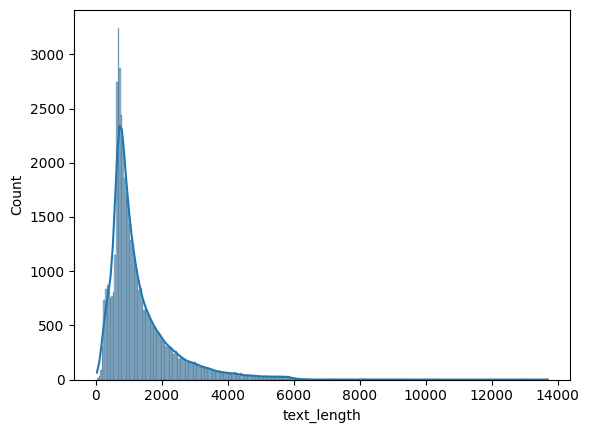

In [13]:
sns.histplot(df['text_length'],kde=True)

## NLP Preprocessing

In [14]:

def clean_text(text):
  # convert in to Lowercase
  text=text.lower()

  # REmove Special Characterese
  text=re.sub(r"http\S+|www\S+","",text)  # Remove urls
  text=re.sub(r"[^a-zA-Z]"," ",text)      # Keep only alphabets
  words=nltk.word_tokenize(text)
  stop_words=set(stopwords.words('english'))
  words=[word for word in words if word not in stop_words]

  # Lemmatization
  lemmatizer=WordNetLemmatizer()
  words=[lemmatizer.lemmatize(word) for word in words]
  return " ".join(words)



In [15]:
df["cleaned_text"]=df["review"].apply(clean_text)

In [16]:
df.head()

,review,sentiment,text_length,cleaned_text
0,One of the other reviewers has mentioned that ...,positive,1761,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,998,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,748,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter mattei love time money visually stunnin...


## Feature Engineering
- BOW
- TF-IDF
- Word2Vec
- Avg Word2Vec

In [17]:
data=df[["cleaned_text","sentiment"]]
data.head()

,cleaned_text,sentiment
0,one reviewer mentioned watching oz episode hoo...,positive
1,wonderful little production br br filming tech...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake think zombie ...,negative
4,petter mattei love time money visually stunnin...,positive


In [18]:
data["label"]=data["sentiment"].map({"positive":1,"negative":0})

/tmp/ipykernel_1665/929650161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["label"]=data["sentiment"].map({"positive":1,"negative":0})


In [19]:
data.head()

,cleaned_text,sentiment,label
0,one reviewer mentioned watching oz episode hoo...,positive,1
1,wonderful little production br br filming tech...,positive,1
2,thought wonderful way spend time hot summer we...,positive,1
3,basically family little boy jake think zombie ...,negative,0
4,petter mattei love time money visually stunnin...,positive,1


In [20]:
X=data['cleaned_text']
y=data['label']

In [21]:
# BOW
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer(max_features=5000)
X_bow=cv.fit_transform(df["cleaned_text"])

In [22]:
# TFIDF
tfidf=TfidfVectorizer(max_features=5000)
X_tfidf=tfidf.fit_transform(df["cleaned_text"])

In [23]:
# # Word2Vec
# Tokenize sentences
sentences = [text.split() for text in df['cleaned_text']]

# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Avg Word2Vec function
vector_size = w2v_model.vector_size

def avg_w2v(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

# Convert all text to vectors
X_avg_w2v = np.array([avg_w2v(text) for text in df['cleaned_text']])

In [24]:
# Train_test split
from sklearn.model_selection import train_test_split
def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models={"LR":LogisticRegression(max_iter=1000,solver='liblinear'),
        "NB":MultinomialNB(),
        "DT":DecisionTreeClassifier(),
        "RF":RandomForestClassifier()}

In [26]:
#
from sklearn.metrics import accuracy_score
def get_acc(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)


In [ ]:
# Comparison of models
from sklearn.metrics import accuracy_score

def get_acc(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

# ==============================
# 7. COMPARISON
# ==============================

import pandas as pd

results = []

for name, model in models.items():

    # BoW
    X_train, X_test, y_train, y_test = split_data(X_bow, y)
    bow = get_acc(model, X_train, X_test, y_train, y_test)

    # TF-IDF
    X_train, X_test, y_train, y_test = split_data(X_tfidf, y)
    tfidf_score = get_acc(model, X_train, X_test, y_train, y_test)

    # Word2Vec (Avg)
    if name == "NB":
        w2v_score = "Not Supported"
    else:
        X_train, X_test, y_train, y_test = split_data(X_avg_w2v, y)
        w2v_score = get_acc(model, X_train, X_test, y_train, y_test)

    # Round values
    bow = round(bow, 3)
    tfidf_score = round(tfidf_score, 3)
    w2v_score = round(w2v_score, 3) if w2v_score != "Not Supported" else w2v_score

    results.append([name, bow, tfidf_score, w2v_score])

# Final DataFrame
df_results = pd.DataFrame(results, columns=["Model", "BoW", "TF-IDF", "Word2Vec"])

print(df_results)

In [ ]:
# Linear Regression gives the best Results
for model in models:
  model.predict("this is a good movie")